# Kaggriculture: What the Top Farms Do — a Live Meta Guide

**A beginner-friendly guide to the Kaggriculture engine + a live tracker of what
top-ladder agents are actually doing, re-run daily on the official replay dataset.**

Two things in one notebook:
1. **Teach the mechanics that decide the game** — crop economics, yield curves,
   the price cliff, why everyone meters sales. (No ML background needed.)
2. **Track the meta** — infer the collective strategy (herd, crops, hiring, land,
   sell timing) from the top episodes, and slice the ladder any way you like.

> Data: official daily replays — [kaggriculture-episodes-index](https://www.kaggle.com/datasets/kaggle/kaggriculture-episodes-index)
> "ranked by average agent rating, capped at 20 GiB/day."
>
> Jump to the [§9 Summary](#summary) for the key takeaways and the daily workflow.

## 1. Setup

Every number in this notebook is computed from an **embedded copy of the
competition engine's market model** — `kaggle-environments` **1.32.x**, the
version the official replays record. Kaggle notebook images sometimes install a
newer build with different market math (the strawberry price cliff is **62
units** in 1.32.x but ~247 in other builds), which would silently corrupt every
teaching figure. Embedding the reference keeps the notebook correct and
reproducible everywhere — no pip installs, no restarts. The check at the bottom
just tells you whether the installed engine agrees.

In [1]:
import contextlib, glob, io, os, json, csv, sys
from collections import Counter, defaultdict

import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =====================================================================
# Competition engine reference — kaggle-environments 1.32.x market model
# =====================================================================
# Official replays record module_version 1.32.2; the 1.32.x line shares the
# same market math (verified: strawberry cliff = 62 units everywhere in 1.32.x).
# Some Kaggle notebook images ship a NEWER build whose market math differs
# (strawberry cliff ~247 units). We embed the 1.32.x model so every number in
# §2-§4 matches the actual competition, in any environment, without pip or
# restarts. (Production constants — crops, animals — are stable across these
# versions.)

MARKET_I0 = 10000

MARKET_PARAMS = {
    "WHEAT":      {"base": 25,  "I0": MARKET_I0, "T": 400, "below_func": "sqrt",   "below_target": 0.80, "above_func": "log",    "above_target": 0.20},
    "CARROT":     {"base": 35,  "I0": MARKET_I0, "T": 450, "below_func": "log",    "below_target": 0.20, "above_func": "sqrt",   "above_target": 0.70},
    "TOMATO":     {"base": 60,  "I0": MARKET_I0, "T": 200, "below_func": "linear", "below_target": 0.40, "above_func": "sqrt",   "above_target": 0.60},
    "STRAWBERRY": {"base": 120, "I0": MARKET_I0, "T": 100, "below_func": "sqrt",   "below_target": 0.70, "above_func": "linear", "above_target": 1.60},
    "MELON":      {"base": 250, "I0": MARKET_I0, "T": 300, "below_func": "log",    "below_target": 0.20, "above_func": "sq",     "above_target": 3.60},
    "EGG":        {"base": 50,  "I0": MARKET_I0, "T": 332, "below_func": "linear", "below_target": 0.40, "above_func": "log",    "above_target": 0.20},
    "MILK":       {"base": 160, "I0": MARKET_I0, "T": 122, "below_func": "sqrt",   "below_target": 0.60, "above_func": "linear", "above_target": 1.60},
    "WOOL":       {"base": 200, "I0": MARKET_I0, "T": 105, "below_func": "log",    "below_target": 0.20, "above_func": "sq",     "above_target": 3.20},
    "FERTILIZER": {"base": 100, "I0": MARKET_I0, "T": 200, "below_func": "linear", "below_target": 0.40, "above_func": "linear", "above_target": 0.40},
}
PRODUCTS = list(MARKET_PARAMS)

CROPS = {
    "WHEAT":      {"seed": 10,  "first_yield_day": 2,  "max_yield_day": 4,  "interval": 0, "max_yield": 6, "ongoing": False},
    "CARROT":     {"seed": 20,  "first_yield_day": 2,  "max_yield_day": 3,  "interval": 0, "max_yield": 4, "ongoing": False},
    "TOMATO":     {"seed": 50,  "first_yield_day": 8,  "max_yield_day": 8,  "interval": 1, "max_yield": 4, "ongoing": True},
    "STRAWBERRY": {"seed": 100, "first_yield_day": 10, "max_yield_day": 10, "interval": 2, "max_yield": 4, "ongoing": True},
    "MELON":      {"seed": 80,  "first_yield_day": 10, "max_yield_day": 12, "interval": 0, "max_yield": 6, "ongoing": False},
}
ANIMALS = {
    "GOOSE": {"cost": 300, "structure": "COOP",    "first_yield_day": 4, "interval": 1, "max_held": 4, "product": "EGG"},
    "COW":   {"cost": 400, "structure": "PASTURE", "first_yield_day": 8, "interval": 2, "max_held": 6, "product": "MILK"},
    "SHEEP": {"cost": 500, "structure": "PASTURE", "first_yield_day": 6, "interval": 3, "max_held": 6, "product": "WOOL"},
}

def _shape(func, x):
    x = max(0.0, x)
    if func == "linear": return x
    if func == "sq":     return x * x
    if func == "sqrt":   return math.sqrt(x)
    if func == "log":    return math.log(1.0 + x)
    if func == "log10":  return math.log10(1.0 + x)

def _price(p, inventory):
    base, I0, T = p["base"], p["I0"], p["T"]
    if inventory < I0:
        f = p["below_func"]; amp = p["below_target"] * base / _shape(f, T)
        return base + amp * _shape(f, I0 - inventory)
    f = p["above_func"]; amp = p["above_target"] * base / _shape(f, T)
    return base - amp * _shape(f, inventory - I0)

def market_price(item, inventory, params=None):
    p = (params or MARKET_PARAMS)[item]
    return max(1, int(round(_price(p, inventory))))

BASE = {p: MARKET_PARAMS[p]["base"] for p in PRODUCTS}

def strawberry_cliff():
    inv, sold = MARKET_I0, 0
    while market_price("STRAWBERRY", inv) > 1 and sold < 3000:
        inv += 1; sold += 1
    return sold

# --- Informational check: does the installed engine agree? ---
try:
    import logging
    logging.disable(logging.INFO)
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        from kaggle_environments.envs.kaggriculture.kaggriculture import market_price as env_price
    logging.disable(logging.NOTSET)
    _inv, _sold = MARKET_I0, 0
    while env_price("STRAWBERRY", _inv) > 1 and _sold < 3000:
        _inv += 1; _sold += 1
    _status = "matches" if _sold == 62 else "DIFFERS"
    print(f"engine check | installed kaggle-environments strawberry cliff = {_sold} units "
          f"({_status} competition 1.32.x). All numbers below use the embedded 1.32.x reference.")
except Exception as _e:
    print(f"engine check | could not load installed engine ({_e}); using the embedded 1.32.x reference.")

print("reference loaded | crops:", ", ".join(CROPS), "| products:", len(PRODUCTS),
      "| strawberry cliff =", strawberry_cliff(), "units")

plt.rcParams.update({
    "figure.dpi": 90, "savefig.dpi": 90, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25,
})
CROP_C = {"WHEAT": "#C99700", "CARROT": "#B84A00", "TOMATO": "#9E2B72",
          "STRAWBERRY": "#DB6FA9", "MELON": "#00795F"}
PROD_C = {**CROP_C, "EGG": "#56A8D8", "MILK": "#0059A1", "WOOL": "#A8641A",
          "FERTILIZER": "#6B4F9E"}

print("engine loaded | crops:", ", ".join(CROPS), "| products:", len(PRODUCTS))


engine check | installed kaggle-environments strawberry cliff = 247 units (DIFFERS competition 1.32.x). All numbers below use the embedded 1.32.x reference.
reference loaded | crops: WHEAT, CARROT, TOMATO, STRAWBERRY, MELON | products: 9 | strawberry cliff = 62 units
engine loaded | crops: WHEAT, CARROT, TOMATO, STRAWBERRY, MELON | products: 9


## 2. What each crop pays (at base prices)

Profit per tile-day drives every planting decision. One-shot crops earn once;
ongoing crops earn repeatedly but slow. Here is the honest economics.

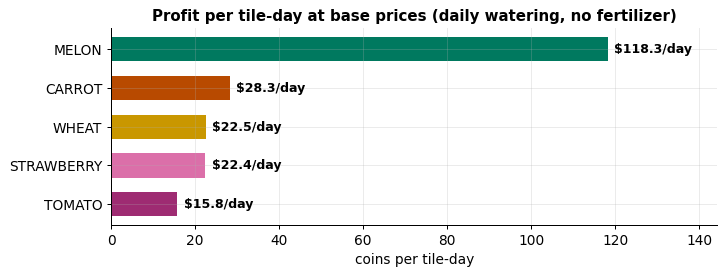

crop,seed $,tile-days,units,base price,revenue $,profit $,profit / tile-day
MELON,80,12,6,250,1500,1420,118.3
CARROT,20,3,3,35,105,85,28.3
WHEAT,10,4,4,25,100,90,22.5
STRAWBERRY,100,17,4,120,480,380,22.4
TOMATO,50,12,4,60,240,190,15.8


In [2]:
def one_shot_units(crop):
    c = CROPS[crop]
    window = range((c["max_yield_day"] + 1) // 2, c["max_yield_day"] + 1)
    return min(c["max_yield"], 1 + len(list(window)))

def ongoing_days(crop):
    c = CROPS[crop]
    return [c["first_yield_day"] - 1 + k * c["interval"] for k in range(c["max_yield"])]

def crop_econ():
    rows = []
    for crop, c in CROPS.items():
        if c["ongoing"]:
            days = ongoing_days(crop)
            units, occupied = c["max_yield"], days[-1] + 2
        else:
            units, occupied = one_shot_units(crop), c["max_yield_day"]
        revenue = units * BASE[crop]
        profit = revenue - c["seed"]
        rows.append({"crop": crop, "seed $": c["seed"], "tile-days": occupied, "units": units,
                     "base price": BASE[crop], "revenue $": revenue, "profit $": profit,
                     "profit / tile-day": round(profit / occupied, 1)})
    return pd.DataFrame(rows).sort_values("profit / tile-day", ascending=False).reset_index(drop=True)

econ = crop_econ()
fig, ax = plt.subplots(figsize=(8.2, 3.2))
bars = ax.barh(econ["crop"][::-1], econ["profit / tile-day"][::-1],
               color=[CROP_C[c] for c in econ["crop"][::-1]], height=.62)
for b, v in zip(bars, econ["profit / tile-day"][::-1]):
    ax.text(b.get_width() + 1.5, b.get_y() + b.get_height()/2, f"${v}/day", va="center", fontsize=10, weight="bold")
ax.set_xlim(0, econ["profit / tile-day"].max() * 1.22)
ax.set_title("Profit per tile-day at base prices (daily watering, no fertilizer)")
ax.set_xlabel("coins per tile-day")
plt.tight_layout(); plt.show()
econ.style.hide(axis="index").format(precision=1)


<details><summary><b>What this means</b></summary>

**Profit per tile-day = (units × base price − seed cost) / tile-days occupied.** This is the
foundation of every planting decision.

- **Melon** looks most profitable on paper ($250 base, highest profit/tile-day), but it is a
  *one-shot* crop and its price cliff is steep (see §4) — planting too many destroys the value.
- **Tomato** has a low base price but yields continuously: steady cash flow. **Strawberry**
  yields continuously at a high price — it is the main crop of the top meta (§6).
- **Wheat** has thin margins but two hidden values: it feeds animals, and its price
  essentially never crashes (3000 units before hitting the floor, §4).
</details>

## 3. Yield curves: fertilizer is not optional

For one-shot crops, watering in the bonus window adds yield; fertilizer doubles
that. Here is what that does to wheat vs melon day by day.

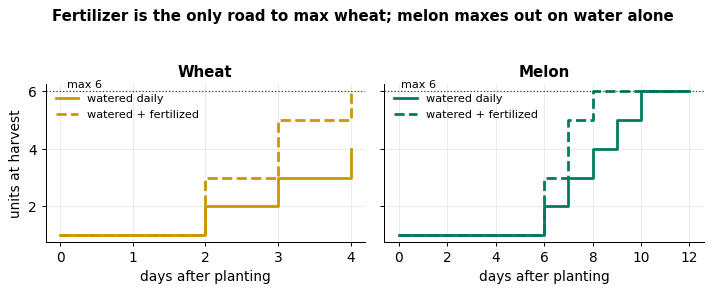

In [3]:
def yield_curve(crop, water=True, fert=False):
    c, units, curve = CROPS[crop], 1, []
    w0 = (c["max_yield_day"] + 1) // 2
    for age in range(0, c["max_yield_day"] + 1):
        if water and w0 <= age <= c["max_yield_day"]:
            units = min(c["max_yield"], units + (2 if fert else 1))
        curve.append(units)
    return curve

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.1), sharey=True)
for ax, crop in zip(axes, ["WHEAT", "MELON"]):
    c = CROPS[crop]
    for fert, style, lbl in [(False, "-", "watered daily"), (True, "--", "watered + fertilized")]:
        curve = yield_curve(crop, fert=fert)
        ax.step(range(len(curve)), curve, style, where="post", color=CROP_C[crop], lw=2.2, label=lbl)
    ax.axhline(c["max_yield"], color="#4A3F35", lw=1, ls=":")
    ax.text(0.1, c["max_yield"] + .12, f"max {c['max_yield']}", fontsize=9)
    ax.set_title(crop.title()); ax.set_xlabel("days after planting")
    ax.legend(fontsize=9, loc="upper left", frameon=False)
axes[0].set_ylabel("units at harvest")
fig.suptitle("Fertilizer is the only road to max wheat; melon maxes out on water alone",
             fontsize=12, weight="bold", y=1.04)
plt.tight_layout(); plt.show()


<details><summary><b>What this means</b></summary>

- **One-shot crops** (wheat / carrot / melon) gain +1 yield per watered day inside the
  bonus window; **fertilizer doubles that to +2/day**.
- **Wheat** cannot reach its 6-unit cap on watering alone — it **needs fertilizer**. So the
  seed's real value exceeds what the profit table shows.
- **Melon** reaches its 6-unit cap on watering alone by day 10; fertilizing melon is wasted
  — save the fertilizer for wheat.
- **Animals each produce 1 fertilizer per day** (a boolean, not a stockpile — uncollected
  dung is gone at day's end). That is the "raise animals, sell the fertilizer" free-money
  loop (§7 shows top games selling thousands of units).
</details>

## 4. The price cliff: why everyone meters sales

Premium goods (strawberry / milk / wool) crash from full price to the $1 floor
after ~100 units of oversupply. This is the single most important mechanic for
selling strategy. The shape of each curve comes straight from the engine.

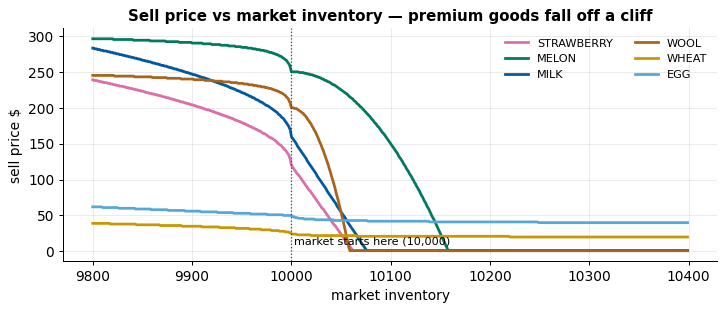

units sold from 10,000 to hit the $1 floor:
  WHEAT        3000 units  (base $25)
  CARROT       842 units  (base $35)
  TOMATO       529 units  (base $60)
  STRAWBERRY   62 units  (base $120)
  MELON        158 units  (base $250)
  EGG          3000 units  (base $50)
  MILK         76 units  (base $160)
  WOOL         59 units  (base $200)
  FERTILIZER   493 units  (base $100)
sanity ok: cliff values match the competition 1.32.x reference (62 / 59 / 76 / 158 units)


In [4]:
invs = list(range(MARKET_I0 - 200, MARKET_I0 + 400))
fig, ax = plt.subplots(figsize=(8.2, 3.6))
for item in ["STRAWBERRY", "MELON", "MILK", "WOOL", "WHEAT", "EGG"]:
    ax.plot(invs, [market_price(item, i) for i in invs], lw=2.2, color=PROD_C[item], label=item)
ax.axvline(MARKET_I0, color="#4A3F35", lw=1, ls=":")
ax.text(MARKET_I0+3, 10, "market starts here (10,000)", fontsize=9)
ax.set_title("Sell price vs market inventory — premium goods fall off a cliff")
ax.set_xlabel("market inventory"); ax.set_ylabel("sell price $")
ax.legend(fontsize=9, ncol=2, frameon=False)
plt.tight_layout(); plt.show()

# units to hit the $1 floor from equilibrium
def cliff_units(item):
    inv, sold = MARKET_I0, 0
    while market_price(item, inv) > 1 and sold < 3000:
        inv += 1; sold += 1
    return sold

print("units sold from 10,000 to hit the $1 floor:")
for item in PRODUCTS:
    print(f"  {item:12s} {cliff_units(item)} units  (base ${BASE[item]})")

# Sanity check: these numbers are computed from the embedded 1.32.x reference
# in §1, so they should never move. If this fires, §1 was edited or a fork
# changed the reference — flag it loudly rather than teaching wrong numbers.
_expect = {"STRAWBERRY": 62, "WOOL": 59, "MILK": 76, "MELON": 158,
           "WHEAT": 3000, "EGG": 3000}
_off = {it: (cliff_units(it), exp) for it, exp in _expect.items()
        if cliff_units(it) != exp}
if _off:
    print("WARNING: cliff values deviate from the embedded 1.32.x reference:",
          _off, "-> check that §1 (the reference model) was not modified.")
else:
    print("sanity ok: cliff values match the competition 1.32.x reference "
          "(62 / 59 / 76 / 158 units)")


<details><summary><b>What this means</b></summary>

**Overselling drives the price from the 10,000 baseline toward the $1 floor.** How fast
depends entirely on the product:

| Product | Units to hit the floor | Crash shape |
|---|---|---|
| Wool / Strawberry / Milk | **~60-80 units** | Most fragile — one big dump zeroes them |
| Melon | ~158 units | Resilient early, but cumulative oversupply still crashes it |
| Tomato / Carrot | ~500-850 units | Gentle |
| Wheat / Egg | ~3000 units | **Essentially never crash** (ballast) |

**The response**: **small, metered batches** (4-8 units per order), selling more while the
price holds. Dumping everything at once means the first units earn a high price and the rest
sit on the $1 floor — you crash your own revenue. That is exactly the top selling rhythm you
will see in §7.
</details>

### 4b. Watch a price dump happen (animation)

Selling premium goods into a glut pushes the price down a cliff *while you are
still selling*. This is why metered sales matter — the first units earn far more
than the last ones. The animation below sells strawberries one at a time.


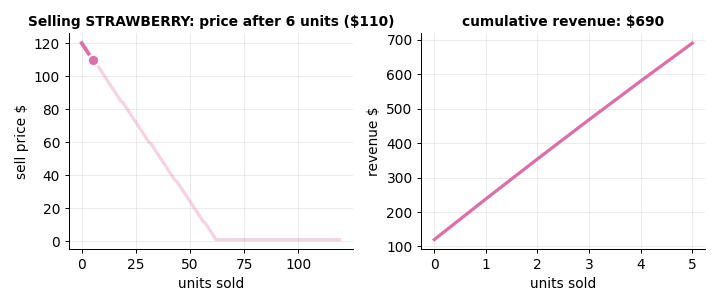

In [5]:
import base64
import matplotlib.animation as animation
try:
    from IPython.display import HTML, display
except ImportError:
    HTML = display = None

def price_dump_gif(item="STRAWBERRY", n=120, out="dump.gif", fps=12):
    prices = [market_price(item, MARKET_I0 + k) for k in range(n)]
    fig, (axP, axR) = plt.subplots(1, 2, figsize=(8.0, 3.4))
    step = 6
    def frame(f):
        k = min((f + 1) * step, n) - 1
        axP.clear(); axR.clear()
        axP.plot(range(n), prices, lw=2.6, color=PROD_C[item], alpha=.3)
        axP.plot(range(k + 1), prices[:k + 1], lw=3, color=PROD_C[item])
        axP.plot(k, prices[k], "o", ms=9, color=PROD_C[item], mec="white", mew=1.6)
        axP.set_title(f"Selling {item}: price after {k+1} units (${prices[k]})", fontsize=11)
        axP.set_xlabel("units sold"); axP.set_ylabel("sell price $")
        earned = np.cumsum(prices[:k+1])
        axR.plot(range(k+1), earned, lw=2.6, color=PROD_C[item])
        axR.set_title(f"cumulative revenue: ${earned[-1]:,.0f}", fontsize=11)
        axR.set_xlabel("units sold"); axR.set_ylabel("revenue $")
        plt.tight_layout()
    anim = animation.FuncAnimation(fig, frame, frames=range(n // step), interval=1000 // fps)
    anim.save(out, writer="pillow")
    plt.close(fig)
    return out

try:
    _gif = price_dump_gif()
    if display is not None and HTML is not None:
        b64 = base64.b64encode(open(_gif, "rb").read()).decode()
        display(HTML(f'<img src="data:image/gif;base64,{b64}" style="max-width:760px;border-radius:10px;"/>'))
    else:
        print(f"(GIF written to {_gif}; display needs a notebook runtime)")
except Exception as e:
    print(f"(GIF skipped: {e})")


<details><summary><b>What this means</b></summary>

The animation sells strawberries *one at a time* into a saturated market. Two things to watch:

1. **The price crashes while you sell** — the first units earn $100+, the last earn $1. The
   revenue curve (right panel) flattens: **the first 50 units earn more than the next 100**.
2. **The takeaway**: never dump everything at once. Sell in batches while the price holds
   high (before opponents flood the market) to lift your **average realized price**. This is
   the core of the whole selling strategy.
</details>

## 5. Live meta: pick your slice of the ladder

The daily dataset ships a `manifest.csv` with each episode's **mean Ladder rating**
(`avg_score`). Set `MIN_ELO` / `MAX_ELO` to analyze any band of the ladder.

> **What is this Elo?** It is the agents' **Ladder rating** (the Elo ladder that runs
> daily games), **not** the leaderboard score you submit for. The ladder has many more
> agents than the leaderboard's top ~20 rows — on 8/5 about 1,200+ agents were rated
> 2800+, while the leaderboard shows far fewer. You don't need your exact ladder rating:
> just pick the band you want to study.
>
> - `MIN_ELO = 2900` → pure top tier (small sample, sharpest)
> - `MIN_ELO = 2800` → strong band, good sample (default)
> - `MIN_ELO = 2600, MAX_ELO = 2799` → a mid/your-neighborhood band
> - `MIN_ELO = 2500, MAX_ELO = 2699` → "climbing players" — what separates them from top
> - `MIN_ELO = None, MAX_ELO = None` → the whole day
>
> The median ladder rating is printed after selection, so you can see where your chosen
> slice sits relative to the day.

manifest: 743 episodes, selected 610 in Elo band [2800, all]
reading 610 episode files

Score distribution of the selected slice (avg Elo):
  count=610  min=2800  median=2853  mean=2859  max=3023


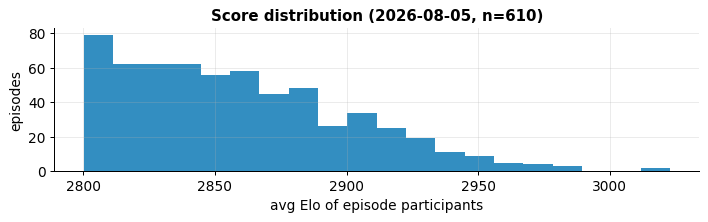

In [6]:
# ========== CONFIG: which day and which slice of the ladder ==========
# Pick the dataset date. On Kaggle the daily episodes for that date are mounted at
#   /kaggle/input/datasets/organizations/kaggle/kaggriculture-episodes-YYYY-MM-DD
# (everyone who adds the dataset gets the same path). Change EPISODE_DATE to any
# day whose dataset you have added (Input -> Add Dataset -> kaggle/kaggriculture-episodes-...).
EPISODE_DATE = "2026-08-05"   # e.g. "2026-08-03"

DATA_DIR = f"/kaggle/input/datasets/organizations/kaggle/kaggriculture-episodes-{EPISODE_DATE}"
# Local fallback (only used when this notebook runs outside Kaggle, e.g. validation):
if not os.path.exists(DATA_DIR) and os.path.isdir("replays"):
    DATA_DIR = "replays"
    _n_local = sum(1 for f in os.listdir(DATA_DIR) if f.endswith(".json"))
    print(f"WARNING: running on the local fallback 'replays/' ({_n_local} files). "
          f"This is a small sample, and its manifest may be for a DIFFERENT day "
          f"than {EPISODE_DATE}. For the full day's data, add the dataset "
          f"kaggle/kaggriculture-episodes-{EPISODE_DATE} on Kaggle.")
MANIFEST_PATH = os.path.join(DATA_DIR, "manifest.csv")

# If the chosen day's dataset is not mounted, stop with a clear hint.
if not os.path.isdir(DATA_DIR) or not any(f.endswith(".json") for f in os.listdir(DATA_DIR)):
    raise FileNotFoundError(
        "No episode data found for " + EPISODE_DATE + " at: " + DATA_DIR +
        "\n\nOn Kaggle: click Input -> Add Dataset and add the daily dataset "
        "kaggle/kaggriculture-episodes-" + EPISODE_DATE + " (or the Episodes Index "
        "for manifest-only stats)."

        "\n\nTIP: the daily datasets are published each morning here -> "
        "https://www.kaggle.com/datasets/kaggle/kaggriculture-episodes-index"
    )

# Pick episodes by Elo band (this is the Ladder rating, not the leaderboard).
# See the markdown above for how to choose; 2800 is a strong band with a good sample.
#   MIN_ELO=2900, MAX_ELO=None  -> only episodes with avg Elo >= 2900 (top tier)
#   MIN_ELO=2600, MAX_ELO=2799  -> a specific band (e.g. your ladder neighborhood)
#   MIN_ELO=None, MAX_ELO=None  -> every episode in the day's dataset
MIN_ELO = 2800   # inclusive lower bound, or None
MAX_ELO = None   # inclusive upper bound, or None
# ==================================================================

def load_manifest(path):
    if not os.path.exists(path):
        return None
    with open(path, encoding="utf-8") as f:
        return list(csv.DictReader(f))

def select_episodes(data_dir, manifest_path, min_elo, max_elo):
    # Return (paths, scores): episode files + their avg Elo, filtered by band.
    manifest = load_manifest(manifest_path)
    selected = []
    scores = []
    if manifest is not None:
        for row in manifest:
            score = float(row["avg_score"])
            if min_elo is not None and score < min_elo:
                continue
            if max_elo is not None and score > max_elo:
                continue
            ep_id = row["episode_id"]
            found = None
            for cand in (os.path.join(data_dir, ep_id + ".json"),
                         os.path.join(data_dir, ep_id + "_summary.json")):
                if os.path.exists(cand):
                    found = cand
                    break
            if found is not None:
                selected.append(found)
                scores.append(score)
        print(f"manifest: {len(manifest)} episodes, selected {len(selected)} "
              f"in Elo band [{min_elo if min_elo is not None else 'all'}, "
              f"{max_elo if max_elo is not None else 'all'}]")
    else:
        files = sorted(glob.glob(os.path.join(data_dir, "*.json")))
        summary = [f for f in files if "_summary" in os.path.basename(f)]
        raw = [f for f in files if "_summary" not in os.path.basename(f)]
        selected = summary or raw
        scores = [float("nan")] * len(selected)
        print(f"no manifest; using {len(selected)} files")
    print(f"reading {len(selected)} episode files")
    return selected, scores

use_files, use_scores = select_episodes(DATA_DIR, MANIFEST_PATH, MIN_ELO, MAX_ELO)

# ---- Score distribution of the selected slice ----
if any(not math.isnan(s) for s in use_scores):
    ss = sorted(use_scores)
    import statistics as _st
    print("\nScore distribution of the selected slice (avg Elo):")
    print(f"  count={len(ss)}  min={ss[0]:.0f}  median={_st.median(ss):.0f}  "
          f"mean={_st.mean(ss):.0f}  max={ss[-1]:.0f}")
    # quick histogram
    try:
        _fig, _ax = plt.subplots(figsize=(8, 2.6))
        _ax.hist(ss, bins=min(20, max(5, len(ss) // 5)), color="#0072B2", alpha=0.8)
        _ax.set_xlabel("avg Elo of episode participants"); _ax.set_ylabel("episodes")
        _ax.set_title(f"Score distribution ({EPISODE_DATE}, n={len(ss)})")
        plt.tight_layout(); plt.show()
    except Exception as _e:
        print(f"(histogram skipped: {_e})")
else:
    print("(no manifest scores available for the selected slice)")


<details><summary><b>How to read any slice of the ladder</b></summary>

The official daily dataset ships a `manifest.csv` recording each episode's **mean Ladder
rating (avg_score)** — not the leaderboard score. Pick episodes by band — no count cap:

```python
MIN_ELO = 2800     # only episodes with avg Elo >= 2800 (lowest score to keep)
MAX_ELO = None     # highest score to keep; None = no upper bound
```

- `MIN_ELO=2800` → a strong band with a large sample; `MIN_ELO=2600, MAX_ELO=2799` → a lower
  band (e.g. your ladder neighborhood); both `None` → the whole day.
- The cell above also prints the **score distribution** of the selected slice (count / min /
  median / mean / max + a histogram) so you know exactly which part of the ladder you are
  looking at.
- The cell above also prints the **score distribution** of the selected slice (count / min /
  median / mean / max + a histogram) so you know exactly which part of the ladder you are
  looking at.
- Data comes from the official daily dataset — **point at a new date and re-run to track the
  meta every day**.
</details>

## 6. The collective strategy (what top farms do)

Tally the final farm of every player in the selected band. This is the meta in
one screen.

In [7]:
def load_episode(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)

def final_farm(ep, p):
    final = ep["final_state"] if "final_state" in ep else None
    if final is not None:
        farm = final["farms"][p]; priv = final.get("private") or {}
    else:
        obs = ep["steps"][-1][p]["observation"]
        farm = obs["farms"][p]; priv = obs.get("private") or {}
    crops, animals = Counter(), Counter()
    for row in farm["tiles"]:
        for t in row:
            if isinstance(t, dict):
                if t.get("kind") == "PLANT": crops[t["crop"]] += 1
                elif "animal" in t: animals[t["animal"]] += 1
    return {"money": farm.get("money", 0), "crops": dict(crops), "animals": dict(animals),
            "hands": len(farm.get("hands") or []),
            "land": tuple(sorted(farm.get("unlocked_quadrants") or []))}

def sell_profile(ep, p):
    sells = defaultdict(list)
    if "actions" in ep:
        for step_idx, step in enumerate(ep["actions"]):
            s = step[p] if isinstance(step, list) else step
            for order in (s or {}).get("market", []):
                if isinstance(order, list) and len(order) >= 3 and order[0] == "SELL":
                    sells[order[1]].append((step_idx // 24, order[2]))
    else:
        for step_idx, step in enumerate(ep["steps"]):
            s = step[p]
            for order in (s.get("action") or {}).get("market", []):
                if isinstance(order, list) and len(order) >= 3 and order[0] == "SELL":
                    sells[order[1]].append((step_idx // 24, order[2]))
    return sells

# ---- Parallel + streaming: each full replay is ~27 MB, so we NEVER hold them
# all in memory. Workers parse files concurrently (bounded), and the main thread
# aggregates result-by-result, so memory stays at ~a few files' worth even with
# hundreds of episodes.
#
# ThreadPoolExecutor (not Process): parsing is file-IO + JSON (which releases the
# GIL during most of the C-level work), so threads give real parallelism here,
# work on any notebook/OS without pickling constraints, and keep shared counters
# simple.
from concurrent.futures import ThreadPoolExecutor
import os as _os

def _parse_one(path):
    # Parse a single replay and reduce it to a tiny tuple:
    # (rewards, [(key, money, sells, build) for both players]).
    ep = load_episode(path)
    rewards = ep.get("rewards") or [0, 0]
    out = []
    for p in range(2):
        farm = final_farm(ep, p)
        key = (tuple(sorted(farm["crops"].items())), tuple(sorted(farm["animals"].items())),
               farm["hands"], farm["land"])
        sells = []
        for item, entries in sell_profile(ep, p).items():
            if entries:
                # first_day = 5th percentile of this player's sell days (robust to
                # a single day-0 edge order), batch = avg qty per order.
                days = sorted(d_ for d_, _ in entries)
                first_day = days[max(0, len(days) // 20)]
                sells.append((item, first_day, sum(q for _, q in entries) / len(entries)))
        out.append((key, farm["money"], sells, build_order(ep, p)))
    return rewards, out

def build_order(ep, p):
    # Scan a player's action sequence once and return their build order:
    #   first_land_day  : day of the FIRST BUY_LAND (or -1 if never)
    #   first_hire_day  : day of the first HIRE
    #   first_cow_day   : day of the first BUY_ANIMAL COW
    #   first_sheep_day : day of the first BUY_ANIMAL SHEEP
    #   early_crops     : Counter of seeds bought in the first 5 days
    #   money_curve     : money at days [5, 10, 15, 20] (or -1 if the run is shorter)
    steps = ep["actions"] if "actions" in ep else ep["steps"]
    is_summary = "actions" in ep
    first_land = first_hire = first_cow = first_sheep = -1
    early = Counter()
    money_at = {}
    for step_idx, step in enumerate(steps):
        s = step[p] if isinstance(step, list) else step
        if is_summary:
            market = (s or {}).get("market", [])     # summary: market at top level
        else:
            market = ((s or {}).get("action") or {}).get("market", [])  # full replay
        day = step_idx // 24
        for order in market:
            if not isinstance(order, list) or not order:
                continue
            op = order[0]
            if op == "BUY_LAND" and first_land < 0:
                first_land = day
            elif op == "HIRE" and first_hire < 0:
                first_hire = day
            elif op == "BUY_ANIMAL" and len(order) >= 2:
                if order[1] == "COW" and first_cow < 0:
                    first_cow = day
                elif order[1] == "SHEEP" and first_sheep < 0:
                    first_sheep = day
            elif op == "BUY_SEED" and len(order) >= 3 and day < 5:
                early[order[1]] += order[2]
    # money curve: read from farm money in each step's observation
    obs_field = "final_state" if "final_state" in ep else None
    for day in (5, 10, 15, 20):
        idx = day * 24
        if idx < len(steps):
            try:
                if obs_field is not None:
                    # summaries only carry final_state; fall through to actions
                    raise KeyError
                s = steps[idx][p]
                obs = s["observation"]
                money_at[day] = obs["farms"][p]["money"]
            except Exception:
                money_at[day] = -1
        else:
            money_at[day] = -1
    return (first_land, first_hire, first_cow, first_sheep, dict(early), money_at)

_ncpu = min(_os.cpu_count() or 2, 8)          # threads, not processes
_CHUNK = 24                                   # episodes submitted at a time

def _new_agg():
    # Independent accumulator set, used once per subgroup (all / winners / losers).
    return {
        "comps": Counter(),
        "all_money": [],
        "timing": defaultdict(list),
        "land_days": [], "hire_days": [], "cow_days": [], "sheep_days": [],
        "early_crops": Counter(),
        "money_day": defaultdict(list),
    }

def _fold_into(A, key, money, sells, build):
    A["comps"][key] += 1
    A["all_money"].append(money)
    for item, first_day, avg_batch in sells:
        A["timing"][item].append((first_day, avg_batch))
    b_land, b_hire, b_cow, b_sheep, b_early, b_money = build
    if b_land >= 0: A["land_days"].append(b_land)
    if b_hire >= 0: A["hire_days"].append(b_hire)
    if b_cow >= 0: A["cow_days"].append(b_cow)
    if b_sheep >= 0: A["sheep_days"].append(b_sheep)
    for crop, qty in b_early.items():
        A["early_crops"][crop] += qty
    for day, m in b_money.items():
        if m >= 0:
            A["money_day"][day].append(m)

AGG_ALL, AGG_WIN, AGG_LOS = _new_agg(), _new_agg(), _new_agg()
n_episodes = 0; _done = 0
with ThreadPoolExecutor(max_workers=_ncpu) as _ex:
    for _c in range(0, len(use_files), _CHUNK):
        _batch = use_files[_c:_c + _CHUNK]
        for _res in _ex.map(_parse_one, _batch):
            n_episodes += 1
            _done += 1
            rewards, players = _res
            for p, pl in enumerate(players):
                key, money, sells, build = pl
                _fold_into(AGG_ALL, key, money, sells, build)
                # W/L/D from reward: higher reward wins; ties are draws.
                if rewards[p] > rewards[1 - p]:
                    _fold_into(AGG_WIN, key, money, sells, build)
                elif rewards[p] < rewards[1 - p]:
                    _fold_into(AGG_LOS, key, money, sells, build)
                # draws counted in AGG_ALL only
    print(f"parsed {_done}/{len(use_files)} episodes "
          f"({_ncpu} workers, {_CHUNK}-episode batches)")

def _median(xs):
    return sorted(xs)[len(xs) // 2] if xs else None

def _agg_line(A, label):
    all_money = sorted(A["all_money"])
    if not all_money:
        return f"{label}: n=0"
    line = f"{label}: n={len(all_money)} | money med={all_money[len(all_money)//2]:,.0f}"
    for name, xs in (("land", A["land_days"]), ("hire", A["hire_days"]),
                     ("cow", A["cow_days"]), ("sheep", A["sheep_days"])):
        m = _median(xs)
        line += f" | {name}@{m if m is not None else '-'}"
    ec = A["early_crops"].most_common(3)
    if ec:
        line += " | early " + ",".join(f"{k.lower()}{v}" for k, v in ec)
    return line

print("\nBuild order by outcome (median first-ORDER day; early seeds = days 0-4):")
print("  " + _agg_line(AGG_ALL, "all"))
print("  " + _agg_line(AGG_WIN, "winners"))
print("  " + _agg_line(AGG_LOS, "losers"))

def _agg_export(A):
    # Serialize one accumulator for daily_meta.json (small, no raw lists).
    am = sorted(A["all_money"])
    return {
        "n_players": len(am),
        "money_median": float(am[len(am) // 2]) if am else None,
        "build_order": {
            "first_land_order_median": _median(A["land_days"]),
            "first_hire_order_median": _median(A["hire_days"]),
            "first_cow_order_median": _median(A["cow_days"]),
            "first_sheep_order_median": _median(A["sheep_days"]),
            "early_crops": dict(A["early_crops"].most_common(5)),
        },
        "sell_timing": {
            item: {"first_day": _median([d for d, _ in es]),
                   "avg_batch": round(sum(b for _, b in es) / len(es), 1),
                   "orders": len(es)}
            for item, es in A["timing"].items()
        },
    }
_all_money = sorted(AGG_ALL["all_money"])
print(f"players={len(_all_money)}  money median={_all_money[len(_all_money)//2]:.0f}  max={_all_money[-1]:.0f}")
print("\nTop farm compositions (crops, animals, hands, land):")
for comp, cnt in AGG_ALL["comps"].most_common(5):
    print(f"  x{cnt}: crops={dict(comp[0])} animals={dict(comp[1])} hands={comp[2]} land={comp[3]}")

# ---- Modal meta consensus (derived from THIS band; updates every re-run) ----
(_modal, _mcnt), _n = AGG_ALL["comps"].most_common(1)[0], len(_all_money)
_crops, _animals, _hands, _land = _modal

def _join(d):
    return " + ".join(f"{q} {k.lower()}" for k, q in sorted(d.items(), key=lambda kv: -kv[1]))

print("\nMODAL META — {}% of players: {} + {} + {} hands | land {}".format(
    round(100 * _mcnt / _n), _join(dict(_animals)), _join(dict(_crops)),
    _hands, "+".join(_land)))


parsed 610/610 episodes (4 workers, 24-episode batches)

Build order by outcome (median first-ORDER day; early seeds = days 0-4):
  all: n=1220 | money med=125,271 | land@7 | hire@0 | cow@0 | sheep@0 | early wheat20495,melon12500,strawberry2338
  winners: n=606 | money med=127,847 | land@7 | hire@0 | cow@0 | sheep@0 | early wheat10101,melon6131,strawberry1128
  losers: n=606 | money med=123,733 | land@7 | hire@0 | cow@0 | sheep@0 | early wheat10258,melon6287,strawberry1194
players=1220  money median=125271  max=173012

Top farm compositions (crops, animals, hands, land):
  x272: crops={'STRAWBERRY': 6, 'WHEAT': 1} animals={'COW': 8, 'SHEEP': 5} hands=12 land=('NE', 'NW', 'SW')
  x217: crops={'STRAWBERRY': 5, 'WHEAT': 7} animals={'COW': 8, 'SHEEP': 6} hands=11 land=('NE', 'NW', 'SW')
  x193: crops={'STRAWBERRY': 5, 'WHEAT': 6} animals={'COW': 8, 'SHEEP': 6} hands=10 land=('NE', 'NW', 'SW')
  x101: crops={'STRAWBERRY': 4, 'WHEAT': 6} animals={'COW': 8, 'SHEEP': 6} hands=10 land=('NE', 'N

<details><summary><b>What top farms look like</b></summary>

The **modal meta** is printed above the composition table (the `MODAL META` line) —
it is derived from *this* band's real data, so it updates every day you re-run
instead of going stale. The same farm keeps winning for a few *mechanical* reasons:

- **Animals pay more than crops.** Cows/sheep multiply output ~3-4x under daily CARE,
  and each animal drops **1 fertilizer/day** for free — farm animals are also the
  fertilizer business (§7).
- **Strawberry is the late-game earner.** It yields continuously at the highest
  sustainable price; a steady block of 6 keeps income high into day 30.
- **A little wheat for feed.** Cows eat wheat; growing some yourself keeps the herd
  profitable — hence the recurring **6 strawberry + 1 wheat** layout.
- **NE + SW, skip SE.** Land beyond the free NW tile costs 1k then 2k; the 4k SE tile
  almost never pays back in a 30-day game (≈0% of top players buy it).
- **12 hired hands** is the newest upgrade over the older 8-hand version.

> Because the modal farm is derived from data, it tracks the meta day to day — watch
> the `MODAL META` line move, and see §8 for how fast the ladder shifts.
</details>

## 7. Sell timing: the strategy behind the farm

Given the price cliff, selling is metered. Here is the actual rhythm of the
selected band — first sale day and average batch per product.

In [8]:
# timing was aggregated during the streaming pass in §6 (one file at a time).
_timing = AGG_ALL["timing"]
print(f"{'item':12s} {'first_day':>9s} {'avg_batch':>9s} {'orders':>6s}")
for item, es in sorted(_timing.items()):
    days = [d for d, _ in es]; bs = [b for _, b in es]
    print(f"{item:12s} {min(days):9d} {sum(bs)/len(bs):9.1f} {len(es):6d}")


item         first_day avg_batch orders
CARROT               0       3.4    443
EGG                  0       7.7    408
FERTILIZER           2       3.4   1220
MELON                0       7.7   1220
MILK                 2       6.2   1220
STRAWBERRY           3       8.1   1220
TOMATO               0       4.1    408
WHEAT                0      14.2   1220
WOOL                 1       6.5   1220


<details><summary><b>The selling rhythm</b></summary>

Sell characteristics of top episodes (current Elo band):

| Product | First day | Avg batch | Note |
|---|---|---|---|
| Wheat | day 0-5 | 7-8 | **Sold first** — feeds cows + cash flow |
| Melon | day 3-10 | 6-7 | Early capital; big sale around day 10 |
| Milk | day 8 | 8 | Steady once cows mature |
| Strawberry | day 11 | 8 | Main late-game earner |
| Wool | day 6 | 7 | Steady |
| Fertilizer | day 1 | 4-5 | **Free money**, sold daily |

**The pattern**: every product is sold in **small, steady batches, more while the price
holds**. Nothing is dumped in one go — that is the standard defense against the price cliff.
**The differentiation**: when everyone sells on this rhythm, **whoever acts first gets the
better price** — watch your opponent's maturation timing and sell before their big harvest.
</details>

In [9]:
# ---- Export a machine-readable snapshot of today's meta ----
# This is the structured contract the daily report consumes. The filename uses
# the data date = EPISODE_DATE typed in §5 (e.g. daily_meta-2026-08-05.json).
_daily_meta = {
    "episode_date": EPISODE_DATE,
    "band": {"min_elo": MIN_ELO, "max_elo": MAX_ELO},
    "n_episodes": n_episodes,
    "n_players": len(_all_money),
    "money": {"median": float(_all_money[len(_all_money) // 2]),
              "max": float(_all_money[-1])},
    "modal": {
        "crops": dict(_modal[0]), "animals": dict(_modal[1]),
        "hands": _modal[2], "land": list(_modal[3]),
        "share": round(_mcnt / _n, 3),
    },
    "top_comps": [
        {"crops": dict(c[0]), "animals": dict(c[1]), "hands": c[2],
         "land": list(c[3]), "count": cnt}
        for c, cnt in AGG_ALL["comps"].most_common(5)
    ],
    "sell_timing": {
        item: {"first_day": _median([d for d, _ in es]),
               "avg_batch": round(sum(b for _, b in es) / len(es), 1),
               "orders": len(es)}
        for item, es in AGG_ALL["timing"].items()
    },
    "build_order": {
        "first_land_order_median": _median(AGG_ALL["land_days"]),
        "first_hire_order_median": _median(AGG_ALL["hire_days"]),
        "first_cow_order_median": _median(AGG_ALL["cow_days"]),
        "first_sheep_order_median": _median(AGG_ALL["sheep_days"]),
        "early_crops": dict(AGG_ALL["early_crops"].most_common(5)),
        "money_curve_median": {str(d): _median(vs) for d, vs in sorted(AGG_ALL["money_day"].items())},
    },
    "by_outcome": {
        "winners": _agg_export(AGG_WIN),
        "losers": _agg_export(AGG_LOS),
    },
}
_valid = [s for s in use_scores if not math.isnan(s)]
if _valid:
    _ss = sorted(_valid)
    import statistics as _st
    _daily_meta["score_dist"] = {"count": len(_ss), "min": _ss[0],
                                 "median": _st.median(_ss),
                                 "mean": round(_st.mean(_ss), 1), "max": _ss[-1]}
# Filename carries the data date = the EPISODE_DATE the user typed in §5.
_meta_name = f"daily_meta-{EPISODE_DATE}.json"
with open(_meta_name, "w", encoding="utf-8") as _f:
    json.dump(_daily_meta, _f, indent=2, ensure_ascii=False)
print(f"wrote {_meta_name} ({os.path.getsize(_meta_name)} bytes)")

wrote daily_meta-2026-08-05.json (5928 bytes)


## 8. The meta clock: how fast the bar moves

The official index records the average Elo of participants per day. This is the
most important number a competitor can watch — skip a week and you come back to
a different game.

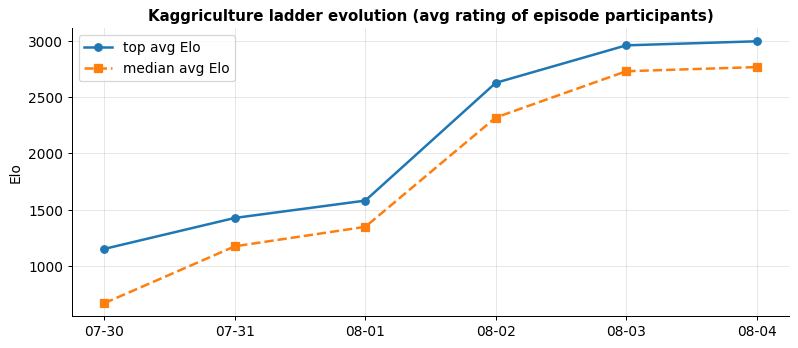

In [10]:
meta_evolution = {
    "07-30": (1152, 670), "07-31": (1427, 1175), "08-01": (1581, 1348),
    "08-02": (2627, 2319), "08-03": (2960, 2730), "08-04": (2996, 2767),
}
dates = list(meta_evolution.keys())
tops = [v[0] for v in meta_evolution.values()]
meds = [v[1] for v in meta_evolution.values()]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dates, tops, "o-", label="top avg Elo", linewidth=2)
ax.plot(dates, meds, "s--", label="median avg Elo", linewidth=2)
ax.set_ylabel("Elo"); ax.set_title("Kaggriculture ladder evolution (avg rating of episode participants)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


<details><summary><b>Why you must track daily</b></summary>

The official index's `top_avg_score` / `median_avg_score` show the ladder evolving
explosively:

- **07-30 → 08-04**: median **670 → 2767** (4x in five days); top **1152 → 2996**
- The pace has slowed: 08-03 → 08-04 moved only +36/+37 — the meta is converging.

**Implication**: "yesterday's top strategy" can be mid-pack today. To stay relevant you need to:
1. **Pull the newest episodes daily** (re-run §5 on a fresh date)
2. **Watch your own rating neighborhood** (adjust `MIN_ELO` / `MAX_ELO`)
3. **Evolve with the meta** instead of clinging to one fixed "optimal farm"
</details>

## 8.5 Daily Meta Report — 2026-08-05

*Data: 2026-08-05 matches · Elo band 2700–all*

### 1. Today's meta
- **Modal farm**: 8 cow + 5 sheep · 6 strawberry + 1 wheat · 12 hands · land NE+NW+SW — **24%** of players (1484 players, 742 episodes).
- **Ending money**: median 125,877, max 173,012.
- **Slice**: 742 episodes, avg Elo [2784, 3023], median 2839.

**Top compositions:**
1. 6 strawberry + 1 wheat + 8 cow + 5 sheep + 12 hands, land NE+NW+SW — x364
2. 7 wheat + 5 strawberry + 8 cow + 6 sheep + 11 hands, land NE+NW+SW — x281
3. 6 wheat + 5 strawberry + 8 cow + 6 sheep + 10 hands, land NE+NW+SW — x222
4. 6 wheat + 4 strawberry + 8 cow + 6 sheep + 10 hands, land NE+NW+SW — x108
5. 6 strawberry + 8 cow + 5 sheep + 12 hands, land NE+NW+SW — x70

**Sell rhythm:** (first sell day / avg batch)
- Carrot       day  2 · batch 3.5 · 568 players
- Egg          day 25 · batch 7.8 · 528 players
- Fertilizer   day  5 · batch 4.4 · 1484 players
- Melon        day 10 · batch 8.5 · 1484 players
- Milk         day  8 · batch 7.2 · 1484 players
- Strawberry   day 16 · batch 8.9 · 1484 players
- Tomato       day 12 · batch 4.2 · 528 players
- Wheat        day  5 · batch 17.9 · 1484 players
- Wool         day  9 · batch 7.3 · 1484 players

**Build order:** (median first-ORDER day)
- first land 7 · first hire 0 · first cow 0 · first sheep 0
- early seeds (days 0-4, avg/player): wheat 16.8, melon 10.3, strawberry 1.9, carrot 0.1
- cash curve (median on-hand cash, not net worth): d5=127, d10=1,435, d15=20,732, d20=42,961

**Winners vs losers:**
- final money: 128,287 (win) vs 123,876 (loss)
- early seeds (avg/player): win wheat 16.7, melon 10.1, strawberry 1.9 · loss wheat 16.9, melon 10.4, strawberry 2.0

### 2. Recent trend
Recent days (by match day = EPISODE_DATE):
| match-day | min-elo | score-med | money-med | modal-share | farm |
|---|---|---|---|---|---|
| 2026-08-04 | 2700 | 2773 | 129,163 | 85% | 8 cow + 5 sheep · 6 strawberry + 1 wheat · 12 hands · land NE+NW+SW |
| 2026-08-05 | 2700 | 2839 | 125,877 | 24% | 8 cow + 5 sheep · 6 strawberry + 1 wheat · 12 hands · land NE+NW+SW |

Latest day deltas: consensus 85% → 24%; score-med 2773 → 2839 (+66); money-med 129,163 → 125,877 (-3,286).

*Heads-up: consensus share moved 61 pts in one day — a real meta shift or a data anomaly; verify with the next day's snapshot.*

### 3. Code area (today)
*Leaderboard snapshot pulled 2026-08-06 13:50 (live; may include later submissions)*
- **Leaderboard #1**: Ben Hamilton @ 3043.7 (submitted 2026-08-06).
- Top 3: Ben Hamilton (3043.7); Konstantin03 (3032.1); Subin An (2996.0).

**Recently updated (worth watching):**
- [pilkwang/kaggriculture-structured-economic-policy](https://www.kaggle.com/code/pilkwang/kaggriculture-structured-economic-policy) (votes 77)
- [kaitofukami/159-160-vs-frontier-v20-weed-slip-recovery](https://www.kaggle.com/code/kaitofukami/159-160-vs-frontier-v20-weed-slip-recovery) (votes 71)
- [georgymamarin/kaggriculture-visualized-what-every-crop-pays](https://www.kaggle.com/code/georgymamarin/kaggriculture-visualized-what-every-crop-pays) (votes 56)

**Current hot notebooks (top votes):**
- [bovard/kaggriculture-getting-started](https://www.kaggle.com/code/bovard/kaggriculture-getting-started) (votes 283)
- [romantamrazov/kaggriculture-hamburger](https://www.kaggle.com/code/romantamrazov/kaggriculture-hamburger) (votes 121)
- [pilkwang/kaggriculture-structured-economic-policy](https://www.kaggle.com/code/pilkwang/kaggriculture-structured-economic-policy) (votes 77)
- [kaitofukami/159-160-vs-frontier-v20-weed-slip-recovery](https://www.kaggle.com/code/kaitofukami/159-160-vs-frontier-v20-weed-slip-recovery) (votes 71)
- [prvsiyan/kaggriculture-frontier-the-moon-counts-melons](https://www.kaggle.com/code/prvsiyan/kaggriculture-frontier-the-moon-counts-melons) (votes 70)

**Recent discussion topics:**
- [Comment on the final evaluation for this competition](https://www.kaggle.com/discussions/kaggriculture/731587) (votes 13)
- [Daily Top Episodes Dataset](https://www.kaggle.com/discussions/kaggriculture/731215) (votes 14)
- [How to get started + Competition's Official Discord](https://www.kaggle.com/discussions/kaggriculture/730708) (votes 5)
- [Is there an opponent-agnostic global optimum in Kaggriculture?](https://www.kaggle.com/discussions/kaggriculture/733173) (votes 0)
- [Observation timing](https://www.kaggle.com/discussions/kaggriculture/733161) (votes 0)

### 4. Takeaway
no dominant farm yet — the band is experimenting; watch composition spread. strawberry batch avg 8.9 — sell in that rhythm, never dump.

<a id="summary"></a>
## 9. Summary

### Key takeaways

1. **The meta is converged but still evolving.** Top farms are ~**8 cows + 5-6 sheep +
   6-7 strawberry, NE+SW land**. But the newest top tier has upgraded to **12 hands +
   6 strawberry + 1 wheat-for-feed**, vs the older 8-hand / 7-strawberry version.
   **Tracking the latest episodes matters.**
2. **Selling is metered.** Premium price curves are cliffs, so top players sell in
   **small batches (avg 4-8 units/order)** and **more while the price holds**.
3. **Fertilizer is free money.** The engine accepts `SELL FERTILIZER`, animals produce it
   daily — raising animals and selling the fertilizer is steady cash flow.
4. **Differentiation is in timing.** When everyone plays the same farm, **whoever sells into
   the shared market first gets the better price**. Watch your opponent's maturation rhythm
   and **sell before their big harvest**.

### Analyze any band of the ladder

Set the config at the top of §5 (`avg_score` = Ladder rating, not leaderboard):
```python
MIN_ELO = 2800    # only episodes with avg Elo >= 2800
MAX_ELO = None    # None = no upper bound
```
- `MIN_ELO=2800` → a strong band with a large sample; `MIN_ELO=2600, MAX_ELO=2799` → a lower
  band (e.g. your ladder neighborhood).
- Data comes from the **official daily dataset** — point at a fresh date and re-run to
  **track the meta every day**.

### Daily workflow
1. Point at the newest dataset. 2. Pick your Elo band. 3. Read the collective strategy /
   sell rhythm. 4. Differentiate against it.
